In [33]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Файлы после распаковки:")
print(os.listdir(extract_path))

Файлы после распаковки:
['Telco-Customer-Churn.csv']


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем датасет
df = pd.read_csv('/content/dataset/Telco-Customer-Churn.csv')

print("Датасет успешно загружен!")
print("Размер:", df.shape)

display(df.head())

Датасет успешно загружен!
Размер: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
# Приводим TotalCharges к числовому типу
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Классификация признаков по смыслу
id_features = ['customerID']

numeric_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

categorical_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

print("Идентификаторы:")
print(id_features)

print("\nЧисловые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Идентификаторы:
['customerID']

Числовые признаки:
['tenure', 'MonthlyCharges', 'TotalCharges']

Категориальные признаки:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [36]:
print("Типы данных после обработки:")
display(df.dtypes.to_frame('Тип данных'))

print("\nПропуски:")
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    'Количество пропусков': missing,
    'Процент пропусков': (missing / len(df) * 100).round(2)
})

display(missing_table)

Типы данных после обработки:


,Тип данных
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Пропуски:


,Количество пропусков,Процент пропусков
customerID,0,0.00
gender,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
tenure,0,0.00
PhoneService,0,0.00
MultipleLines,0,0.00
InternetService,0,0.00
OnlineSecurity,0,0.00


In [37]:
numeric_stats = df[numeric_features].describe().T

numeric_stats['median'] = df[numeric_features].median()
numeric_stats['missing'] = df[numeric_features].isnull().sum()

display(numeric_stats)

,count,mean,std,min,25%,50%,75%,max,median,missing
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00,29.000,0
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75,70.350,0
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80,1397.475,11


## 2. Анализ распределения числовых признаков

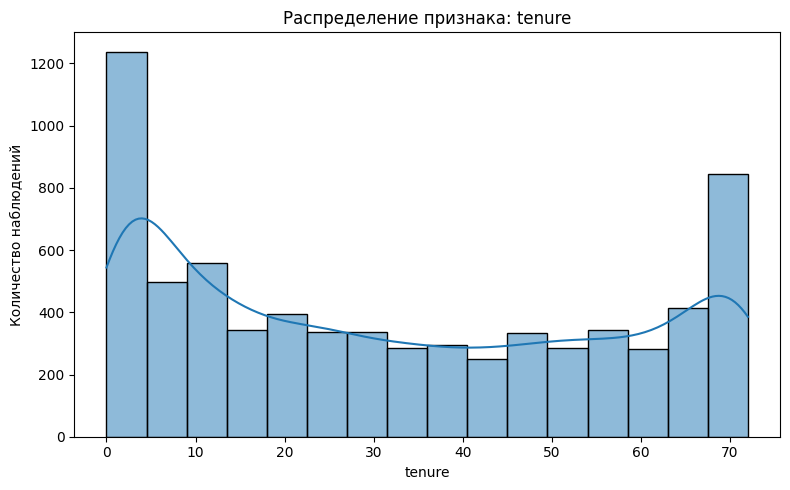

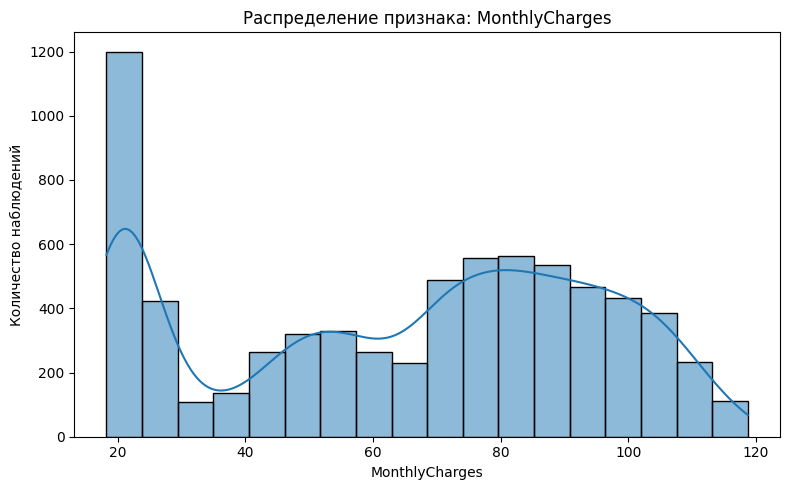

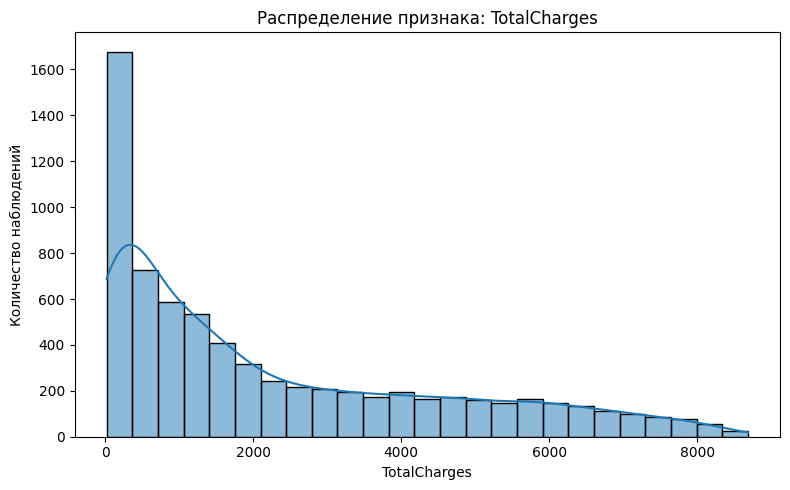

In [38]:
for col in numeric_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(df[col].dropna(), kde=True)

    plt.title(f'Распределение признака: {col}')
    plt.xlabel(col)
    plt.ylabel('Количество наблюдений')
    plt.tight_layout()
    plt.show()

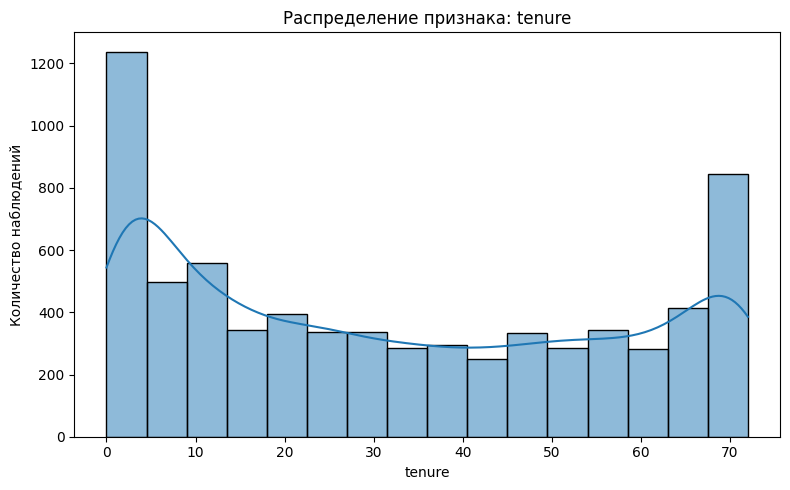

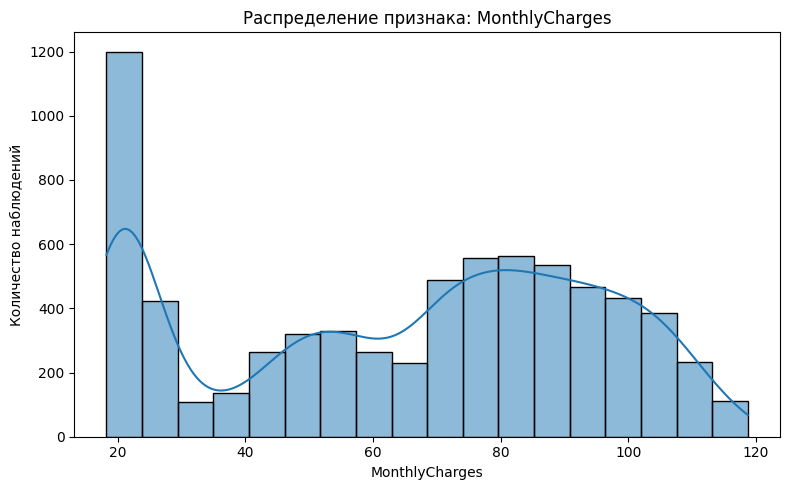

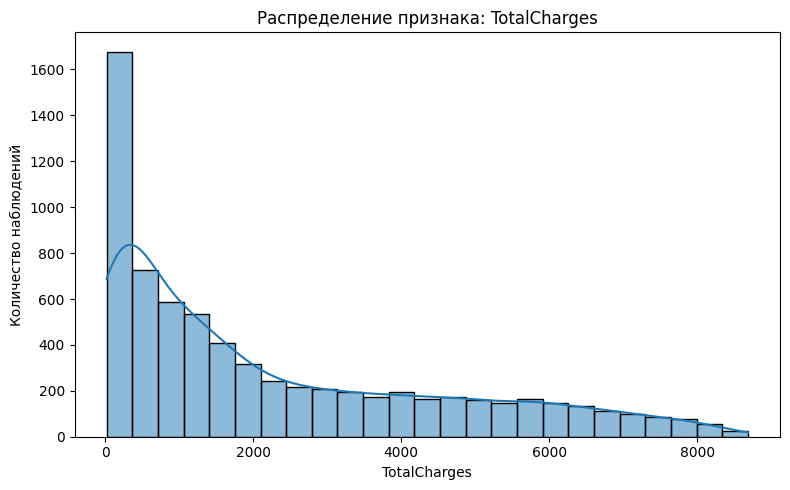

In [39]:
for col in numeric_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(df[col].dropna(), kde=True)

    plt.title(f'Распределение признака: {col}')
    plt.xlabel(col)
    plt.ylabel('Количество наблюдений')
    plt.tight_layout()
    plt.show()

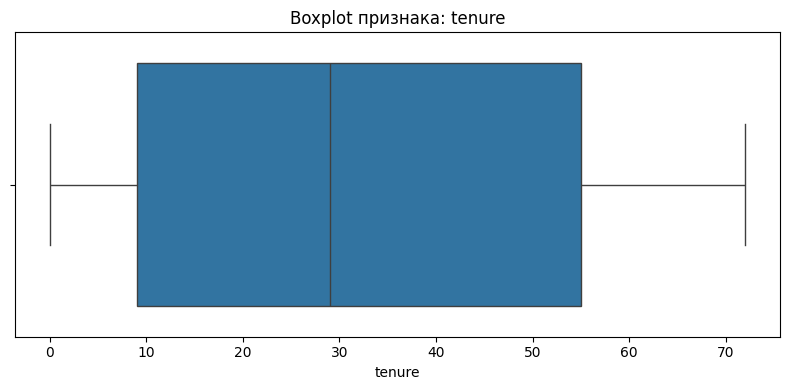

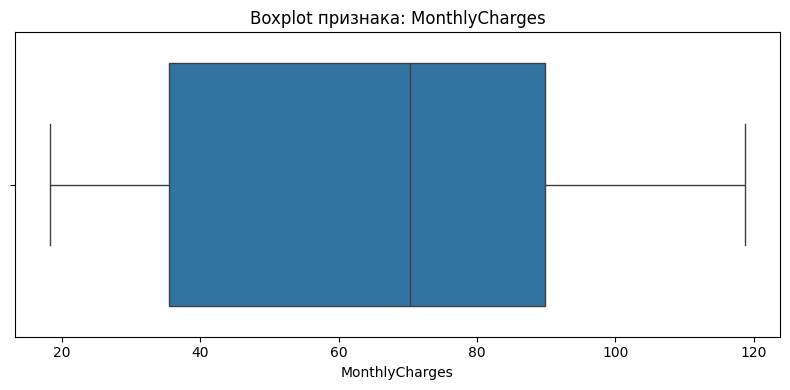

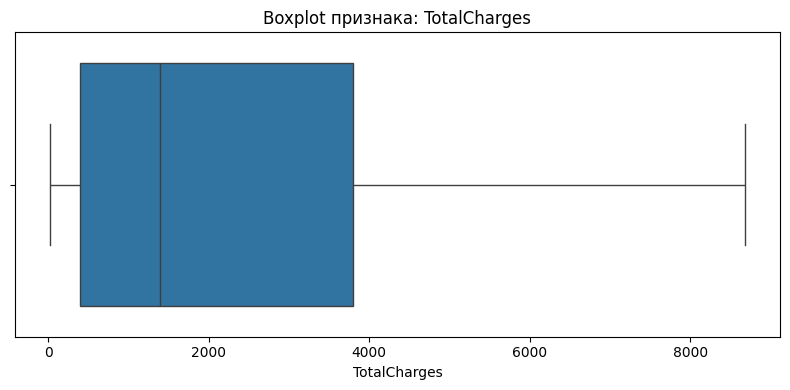

In [40]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot признака: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [41]:
outlier_results = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_results.append({
        'Признак': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Нижняя граница': round(lower_bound, 2),
        'Верхняя граница': round(upper_bound, 2),
        'Количество выбросов': len(outliers),
        'Процент выбросов': round(len(outliers) / len(df) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_results)

display(outlier_table)

,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Количество выбросов,Процент выбросов
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0.0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0,0.0


## 2.1 Анализ категориальных признаков

In [42]:
for col in categorical_features:
    print("=" * 70)
    print(f"Признак: {col}")
    print(f"Количество уникальных категорий: {df[col].nunique()}")

    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame('Количество')
    )

Признак: gender
Количество уникальных категорий: 2


,Количество
gender,
Male,3555
Female,3488


Признак: SeniorCitizen
Количество уникальных категорий: 2


,Количество
SeniorCitizen,
0,5901
1,1142


Признак: Partner
Количество уникальных категорий: 2


...

,Количество
PaperlessBilling,
Yes,4171
No,2872


Признак: PaymentMethod
Количество уникальных категорий: 4


,Количество
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


Признак: Churn
Количество уникальных категорий: 2


,Количество
Churn,
No,5174
Yes,1869


In [43]:
for col in categorical_features:
    print("=" * 70)
    print(f"Признак: {col}")

    freq = df[col].value_counts(normalize=True, dropna=False) * 100

    freq_table = freq.round(2).to_frame('Процент')

    display(freq_table)

Признак: gender


,Процент
gender,
Male,50.48
Female,49.52


Признак: SeniorCitizen


,Процент
SeniorCitizen,
0,83.79
1,16.21


Признак: Partner


...

,Процент
PaperlessBilling,
Yes,59.22
No,40.78


Признак: PaymentMethod


,Процент
PaymentMethod,
Electronic check,33.58
Mailed check,22.89
Bank transfer (automatic),21.92
Credit card (automatic),21.61


Признак: Churn


,Процент
Churn,
No,73.46
Yes,26.54


In [44]:
rare_results = []

for col in categorical_features:
    frequencies = df[col].value_counts(normalize=True, dropna=False) * 100

    rare = frequencies[frequencies < 1]

    rare_results.append({
        'Признак': col,
        'Количество категорий': df[col].nunique(),
        'Количество редких категорий': len(rare),
        'Редкие категории': ', '.join(
            [str(x) for x in rare.index]
        ) if len(rare) > 0 else 'Нет'
    })

rare_table = pd.DataFrame(rare_results)

display(rare_table)

,Признак,Количество категорий,Количество редких категорий,Редкие категории
0,gender,2,0,Нет
1,SeniorCitizen,2,0,Нет
2,Partner,2,0,Нет
3,Dependents,2,0,Нет
4,PhoneService,2,0,Нет
5,MultipleLines,3,0,Нет
6,InternetService,3,0,Нет
7,OnlineSecurity,3,0,Нет
8,OnlineBackup,3,0,Нет
9,DeviceProtection,3,0,Нет


In [45]:
rare_results = []

for col in categorical_features:
    frequencies = df[col].value_counts(normalize=True, dropna=False) * 100

    rare = frequencies[frequencies < 1]

    rare_results.append({
        'Признак': col,
        'Количество категорий': df[col].nunique(),
        'Количество редких категорий': len(rare),
        'Редкие категории': ', '.join(
            [str(x) for x in rare.index]
        ) if len(rare) > 0 else 'Нет'
    })

rare_table = pd.DataFrame(rare_results)

display(rare_table)

,Признак,Количество категорий,Количество редких категорий,Редкие категории
0,gender,2,0,Нет
1,SeniorCitizen,2,0,Нет
2,Partner,2,0,Нет
3,Dependents,2,0,Нет
4,PhoneService,2,0,Нет
5,MultipleLines,3,0,Нет
6,InternetService,3,0,Нет
7,OnlineSecurity,3,0,Нет
8,OnlineBackup,3,0,Нет
9,DeviceProtection,3,0,Нет


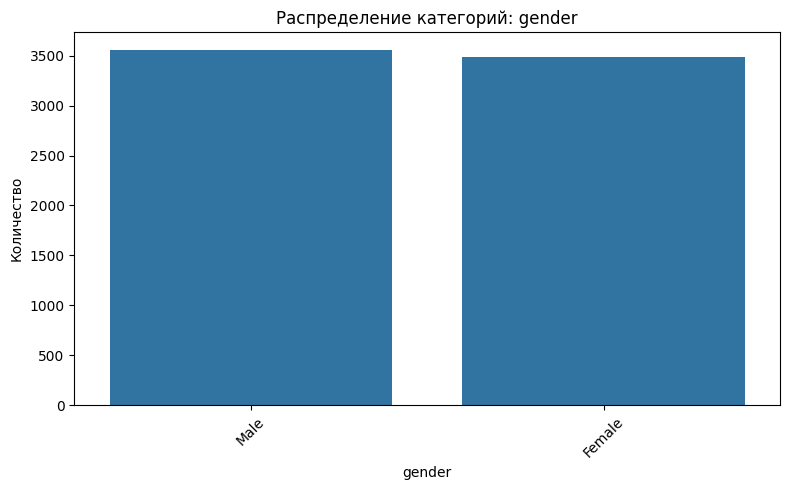

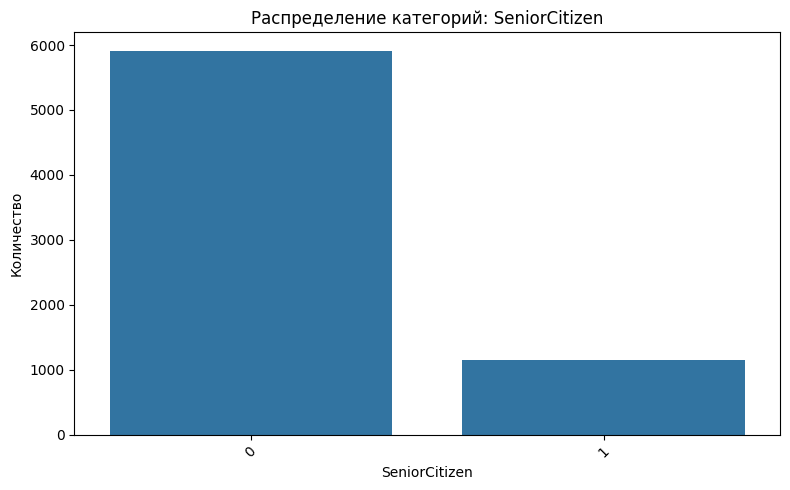

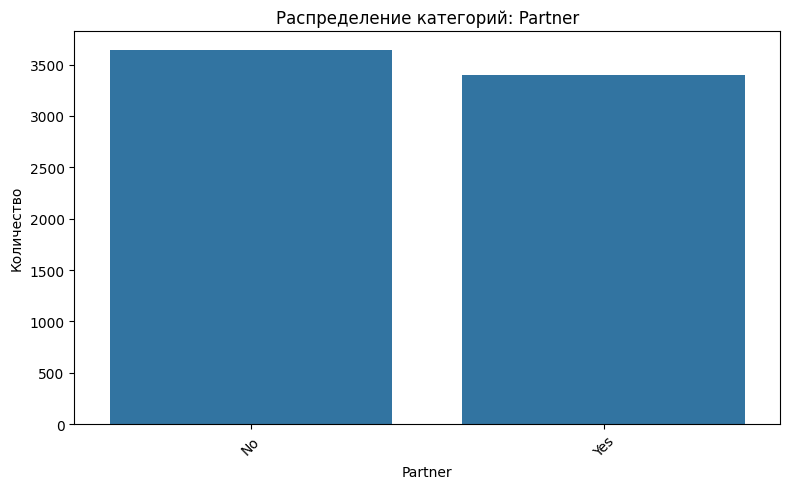

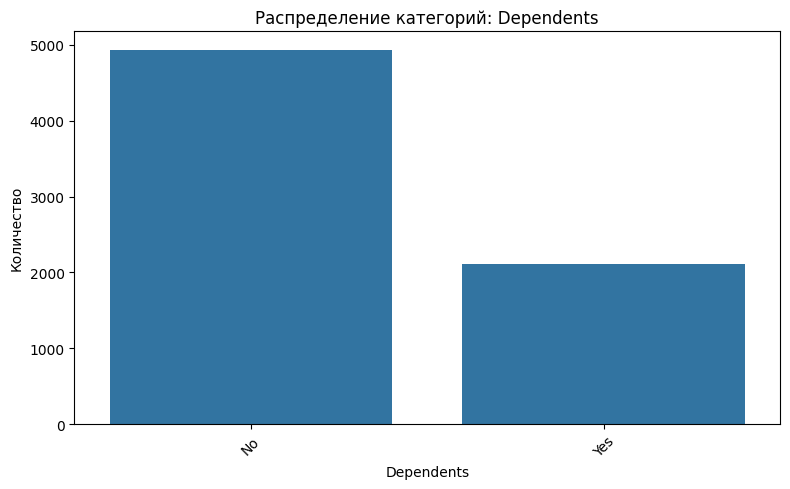

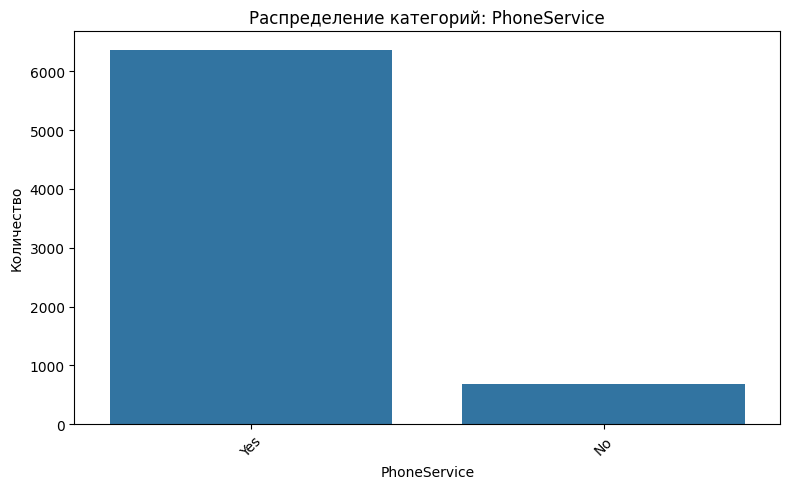

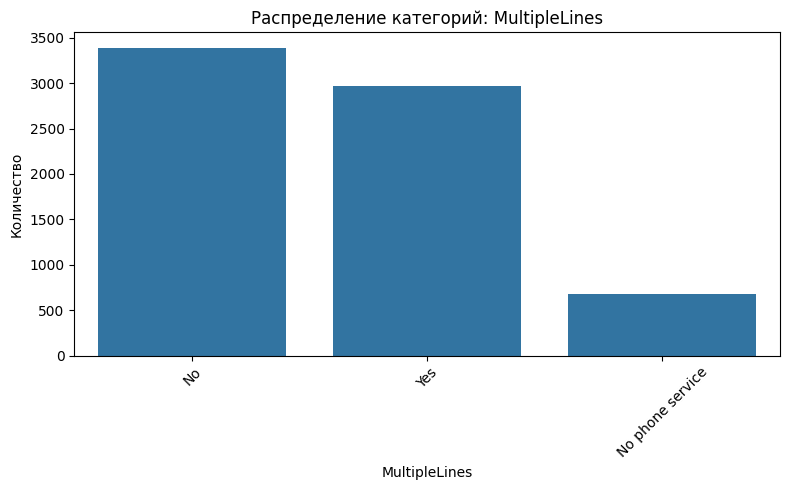

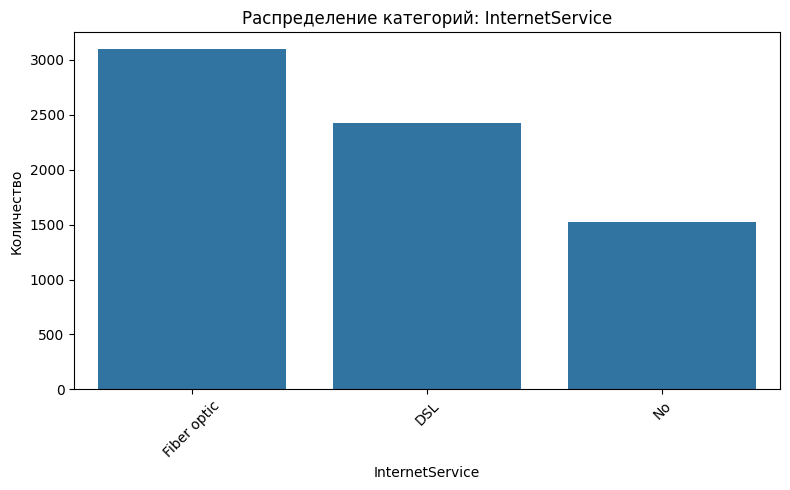

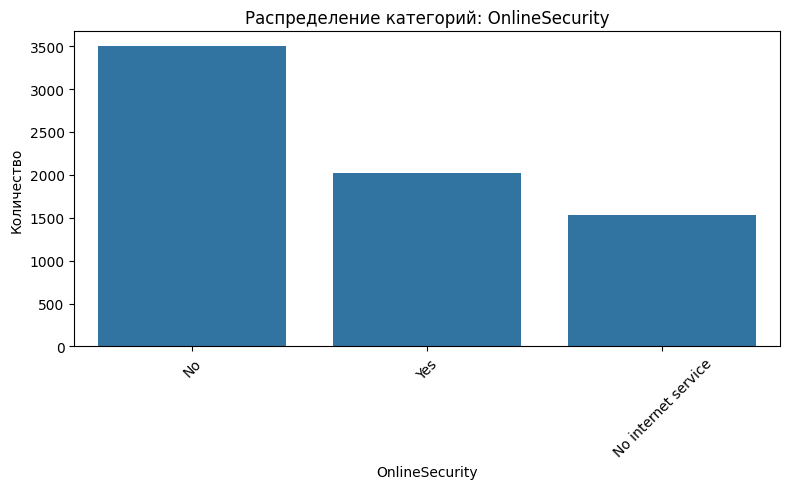

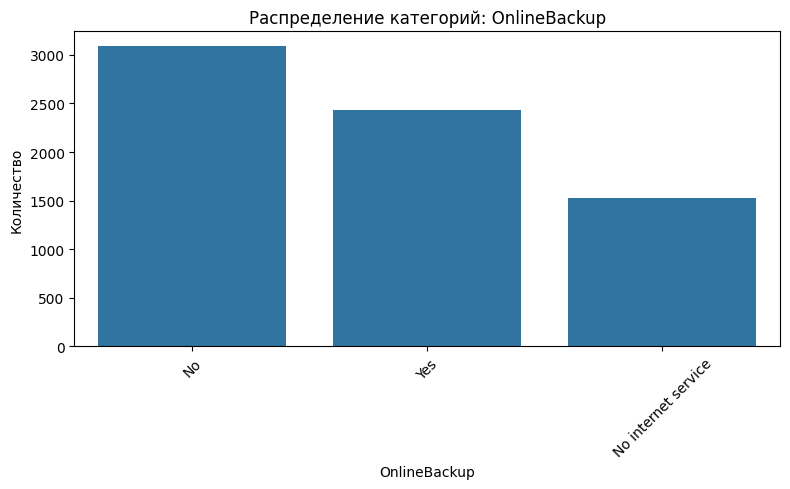

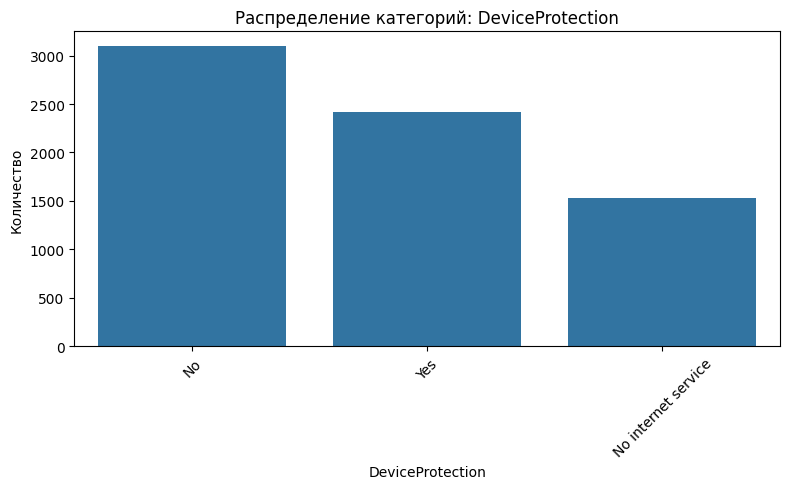

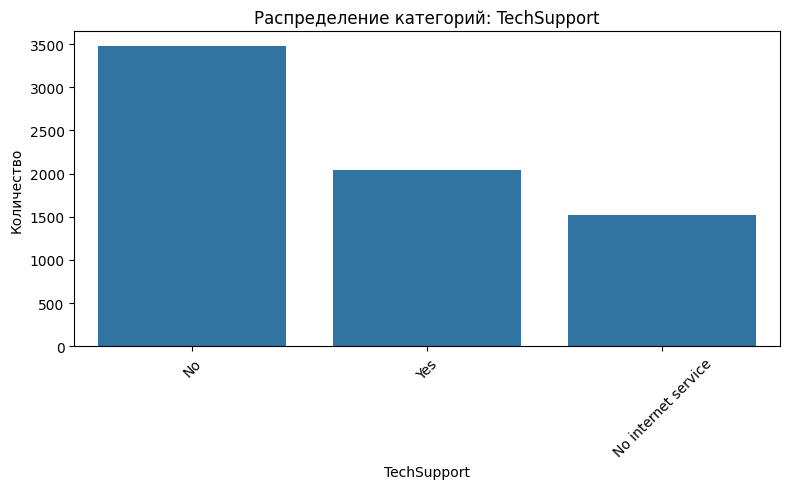

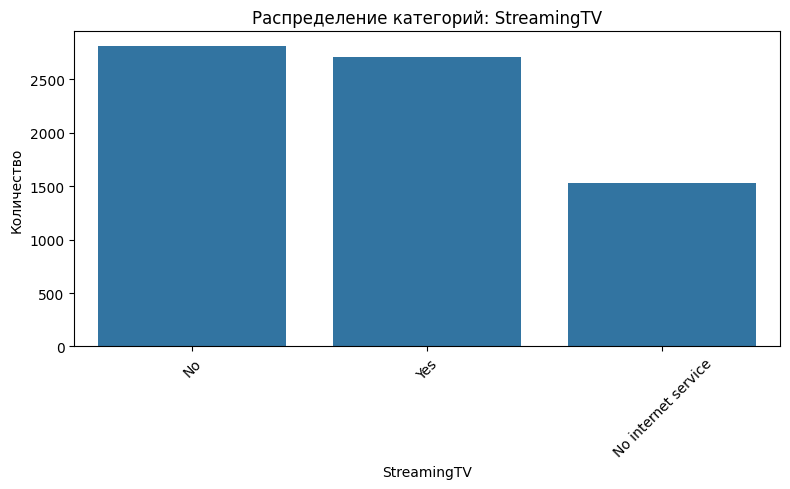

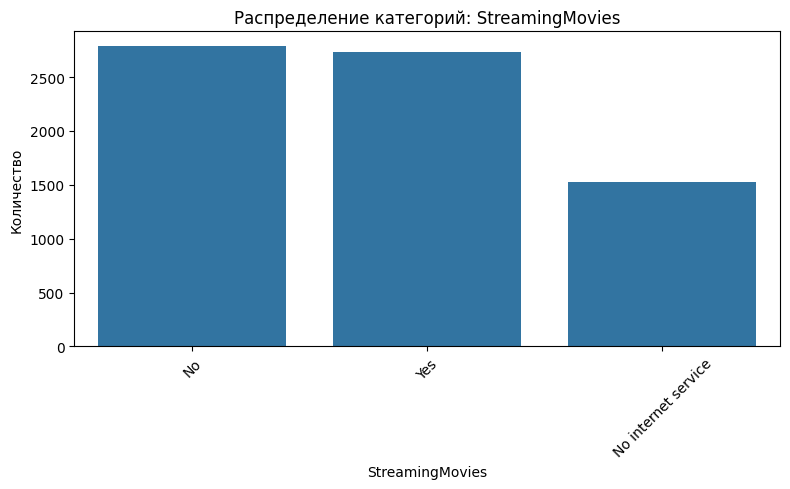

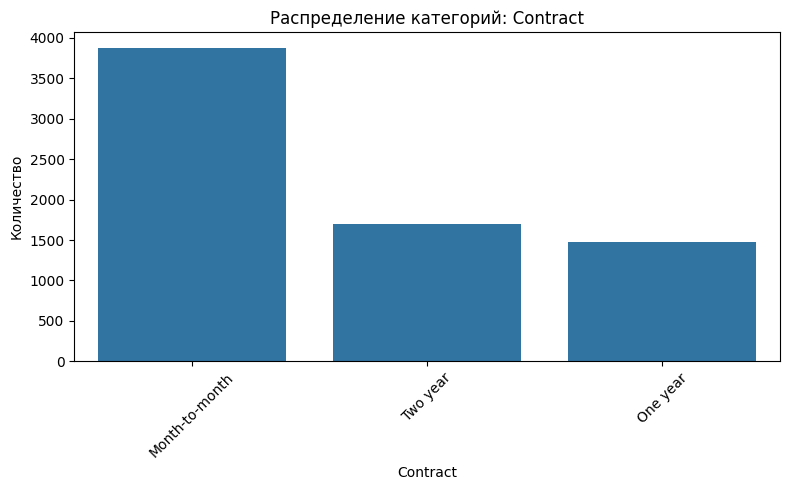

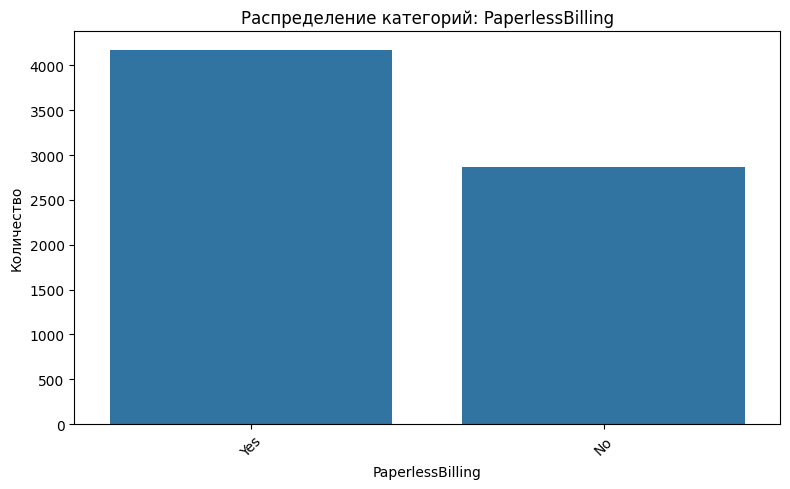

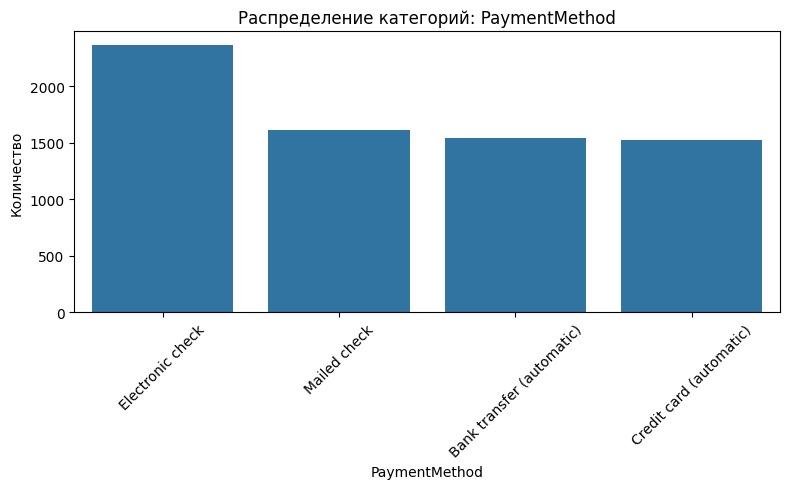

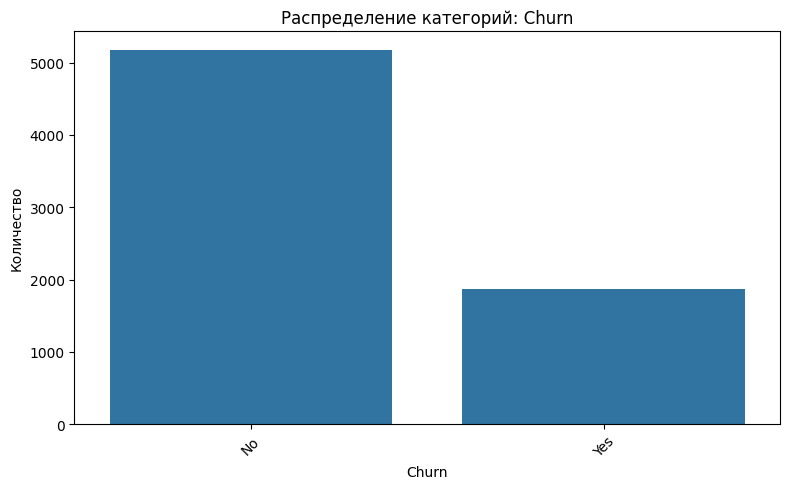

In [46]:
for col in categorical_features:

    # Не строим слишком большие графики
    if df[col].nunique() <= 10:

        plt.figure(figsize=(8, 5))

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order
        )

        plt.title(f'Распределение категорий: {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## 3. Корреляционная матрица числовых признаков

In [47]:
corr_matrix = df[numeric_features].corr()

display(corr_matrix)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


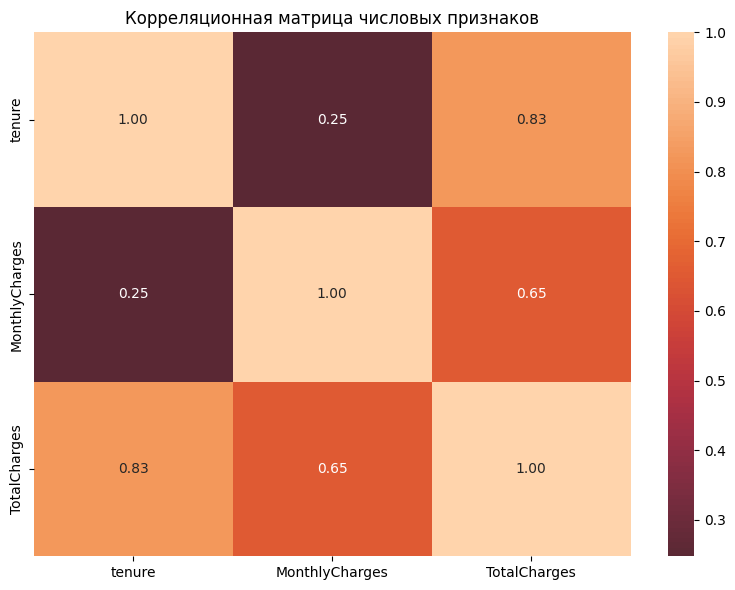

In [48]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    center=0
)

plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

In [49]:
corr_pairs = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = (
    corr_pairs
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    'Признак 1',
    'Признак 2',
    'Корреляция'
]

corr_pairs['Абсолютная корреляция'] = (
    corr_pairs['Корреляция'].abs()
)

corr_pairs = corr_pairs.sort_values(
    'Абсолютная корреляция',
    ascending=False
)

display(corr_pairs)

,Признак 1,Признак 2,Корреляция,Абсолютная корреляция
1,tenure,TotalCharges,0.825880,0.825880
2,MonthlyCharges,TotalCharges,0.651065,0.651065
0,tenure,MonthlyCharges,0.247900,0.247900


In [50]:
corr_pairs = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = (
    corr_pairs
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    'Признак 1',
    'Признак 2',
    'Корреляция'
]

corr_pairs['Абсолютная корреляция'] = (
    corr_pairs['Корреляция'].abs()
)

corr_pairs = corr_pairs.sort_values(
    'Абсолютная корреляция',
    ascending=False
)

display(corr_pairs)

,Признак 1,Признак 2,Корреляция,Абсолютная корреляция
1,tenure,TotalCharges,0.825880,0.825880
2,MonthlyCharges,TotalCharges,0.651065,0.651065
0,tenure,MonthlyCharges,0.247900,0.247900


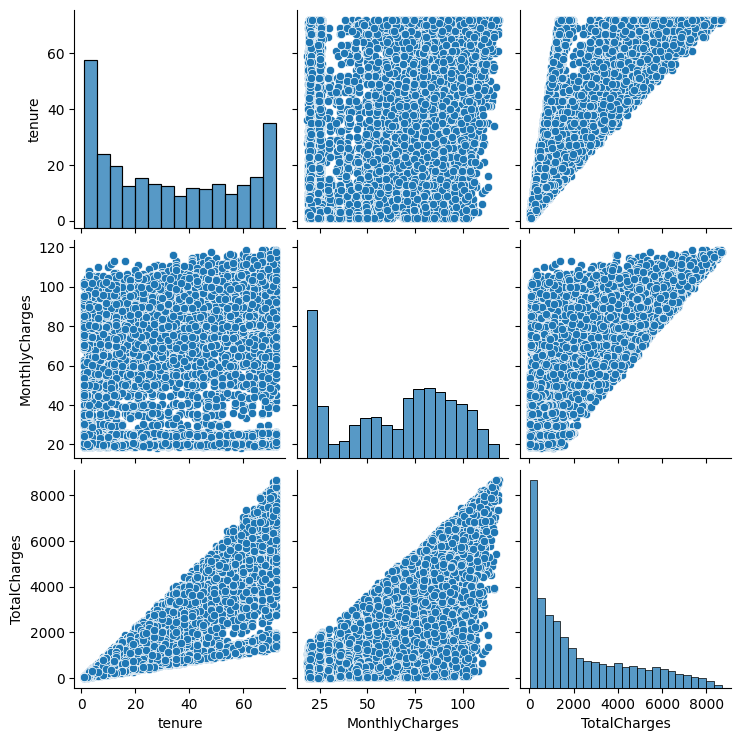

In [51]:
sns.pairplot(
    df[numeric_features].dropna(),
    diag_kind='hist'
)

plt.show()

## 4. Анализ дисбаланса целевой переменной

Целевая переменная: `Churn`.

Она показывает, ушёл ли клиент из компании:
- `Yes` — клиент ушёл;
- `No` — клиент остался.

In [52]:
target = 'Churn'

target_counts = df[target].value_counts()
target_percent = df[target].value_counts(normalize=True) * 100

target_table = pd.DataFrame({
    'Количество': target_counts,
    'Процент': target_percent.round(2)
})

display(target_table)

,Количество,Процент
Churn,,
No,5174,73.46
Yes,1869,26.54


In [53]:
target = 'Churn'

target_counts = df[target].value_counts()
target_percent = df[target].value_counts(normalize=True) * 100

target_table = pd.DataFrame({
    'Количество': target_counts,
    'Процент': target_percent.round(2)
})

display(target_table)

,Количество,Процент
Churn,,
No,5174,73.46
Yes,1869,26.54


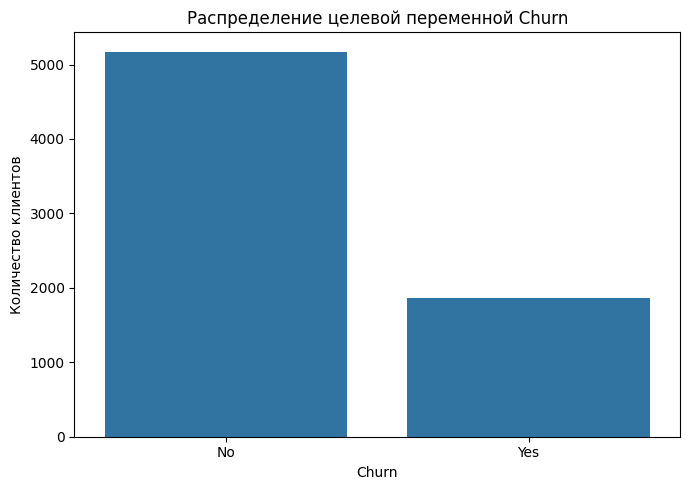

In [54]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Churn',
    order=df['Churn'].value_counts().index
)

plt.title('Распределение целевой переменной Churn')
plt.xlabel('Churn')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

In [55]:
majority_class = target_percent.idxmax()
minority_class = target_percent.idxmin()

majority_percent = target_percent.max()
minority_percent = target_percent.min()

imbalance_ratio = majority_percent / minority_percent

print(f"Наибольший класс: {majority_class} — {majority_percent:.2f}%")
print(f"Меньший класс: {minority_class} — {minority_percent:.2f}%")
print(f"Отношение долей классов: {imbalance_ratio:.2f}")

Наибольший класс: No — 73.46%
Меньший класс: Yes — 26.54%
Отношение долей классов: 2.77


In [56]:
selected_categories = [
    'Contract',
    'InternetService',
    'PaymentMethod',
    'SeniorCitizen'
]

for col in selected_categories:

    churn_table = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100

    print("=" * 70)
    print(f'{col} — процент Churn внутри каждой категории')

    display(churn_table.round(2))

Contract — процент Churn внутри каждой категории


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


InternetService — процент Churn внутри каждой категории


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


PaymentMethod — процент Churn внутри каждой категории


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


SeniorCitizen — процент Churn внутри каждой категории


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


<Figure size 900x500 with 0 Axes>

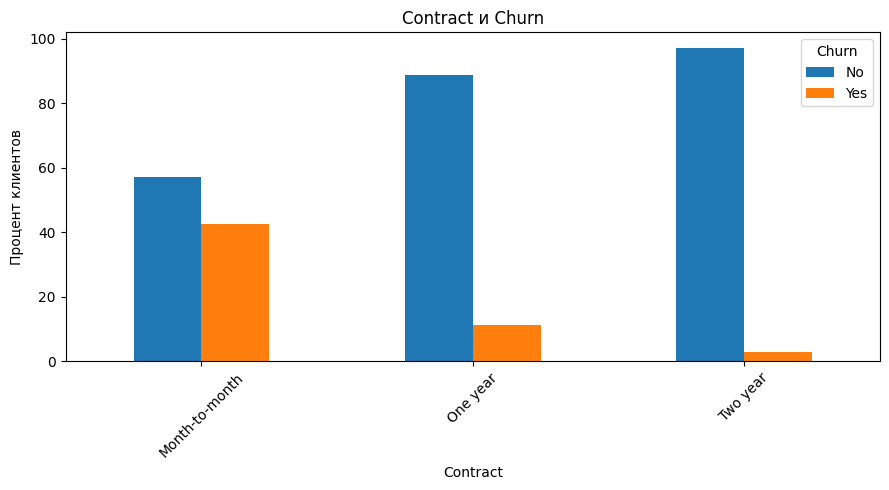

<Figure size 900x500 with 0 Axes>

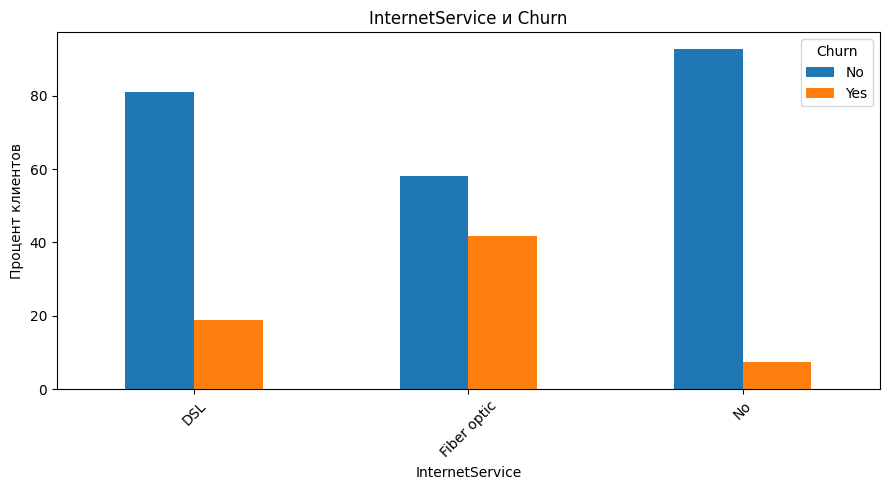

<Figure size 900x500 with 0 Axes>

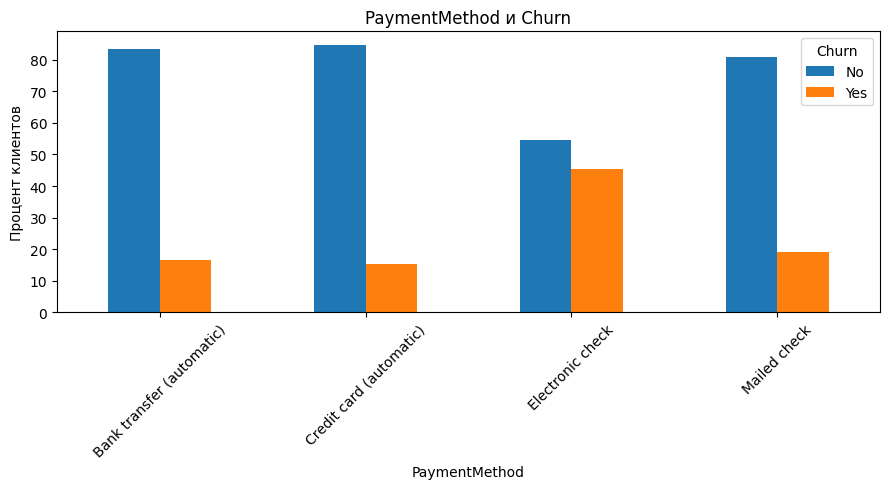

<Figure size 900x500 with 0 Axes>

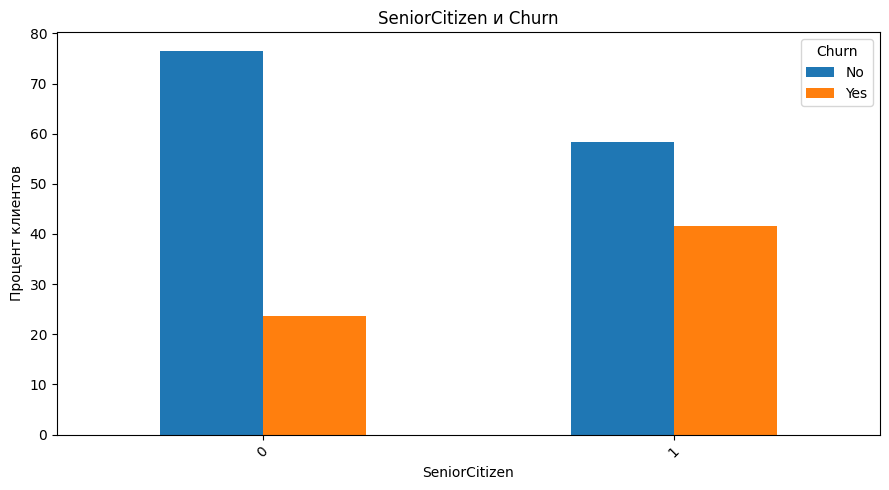

In [57]:
for col in selected_categories:

    plt.figure(figsize=(9, 5))

    churn_percent = (
        pd.crosstab(
            df[col],
            df['Churn'],
            normalize='index'
        ) * 100
    )

    churn_percent.plot(
        kind='bar',
        figsize=(9, 5)
    )

    plt.title(f'{col} и Churn')
    plt.xlabel(col)
    plt.ylabel('Процент клиентов')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [58]:
print("Проверка customerID:")

print("Количество уникальных customerID:",
      df['customerID'].nunique())

print("Количество строк:",
      len(df))

print("\nКоличество дубликатов строк:",
      df.duplicated().sum())

print("\nКоличество повторяющихся customerID:",
      df['customerID'].duplicated().sum())

Проверка customerID:
Количество уникальных customerID: 7043
Количество строк: 7043

Количество дубликатов строк: 0

Количество повторяющихся customerID: 0


In [59]:
print("=" * 70)
print("ФИНАЛЬНАЯ СВОДКА EDA")
print("=" * 70)

print(f"\nРазмер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")

print("\nПропуски:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nПолных дубликатов:", df.duplicated().sum())

print("\nЧисловые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

print("\nЦелевая переменная:", target)

print("\nКлассы целевой переменной:")
display(target_table)

print("\nПотенциальные выбросы:")
display(outlier_table)

print("\nРедкие категории:")
display(rare_table)

ФИНАЛЬНАЯ СВОДКА EDA

Размер датасета: 7043 строк × 21 столбцов

Пропуски:
TotalCharges    11
dtype: int64

Полных дубликатов: 0

Числовые признаки:
['tenure', 'MonthlyCharges', 'TotalCharges']

Категориальные признаки:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Целевая переменная: Churn

Классы целевой переменной:


,Количество,Процент
Churn,,
No,5174,73.46
Yes,1869,26.54



Потенциальные выбросы:


,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Количество выбросов,Процент выбросов
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0.0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0,0.0



Редкие категории:


,Признак,Количество категорий,Количество редких категорий,Редкие категории
0,gender,2,0,Нет
1,SeniorCitizen,2,0,Нет
2,Partner,2,0,Нет
3,Dependents,2,0,Нет
4,PhoneService,2,0,Нет
5,MultipleLines,3,0,Нет
6,InternetService,3,0,Нет
7,OnlineSecurity,3,0,Нет
8,OnlineBackup,3,0,Нет
9,DeviceProtection,3,0,Нет


In [60]:
# Получаем данные для отчёта

total_missing = int(df.isnull().sum().sum())
duplicates = int(df.duplicated().sum())

outlier_columns = outlier_table[
    outlier_table['Количество выбросов'] > 0
]

rare_columns = rare_table[
    rare_table['Количество редких категорий'] > 0
]

strong_corr = corr_pairs[
    corr_pairs['Абсолютная корреляция'] >= 0.7
]

majority_percent = target_percent.max()
minority_percent = target_percent.min()

print("ИТОГОВЫЙ ОТЧЁТ")
print("=" * 70)

print("\n1. Структура данных.")
print(
    f"Датасет содержит {df.shape[0]} строк и {df.shape[1]} столбцов. "
    f"В нём присутствуют числовые и категориальные признаки, "
    f"а также идентификатор клиента customerID."
)

print("\n2. Пропуски.")
if total_missing > 0:
    print(
        f"Обнаружено {total_missing} пропущенных значений. "
        f"На следующем этапе их необходимо обработать."
    )
else:
    print(
        "После преобразования типов пропущенные значения "
        "не представляют существенной проблемы."
    )

print("\n3. Выбросы.")
if len(outlier_columns) > 0:
    print(
        f"Потенциальные выбросы по правилу IQR обнаружены "
        f"в {len(outlier_columns)} числовых признаках. "
        f"На следующем этапе их необходимо дополнительно проверить."
    )
else:
    print(
        "Потенциальных выбросов по правилу IQR не обнаружено."
    )

print("\n4. Категориальные признаки.")
if len(rare_columns) > 0:
    print(
        f"Редкие категории обнаружены в {len(rare_columns)} признаках. "
        f"При подготовке модели такие категории необходимо рассмотреть "
        f"для возможного объединения."
    )
else:
    print(
        "Редких категорий с частотой менее 1% не обнаружено."
    )

print("\n5. Корреляции.")
if len(strong_corr) > 0:
    print(
        f"Обнаружено {len(strong_corr)} пар признаков "
        f"с сильной корреляцией (|r| >= 0.7). "
        f"Их взаимосвязь необходимо учитывать при построении модели."
    )
else:
    print(
        "Очень сильных корреляций (|r| >= 0.7) не обнаружено."
    )

print("\n6. Целевая переменная.")
print(
    f"Для Churn доля самого большого класса составляет "
    f"{majority_percent:.2f}%, а меньшего — {minority_percent:.2f}%. "
    f"Следовательно, при построении классификационной модели "
    f"необходимо учитывать распределение классов."
)

print("\n7. План дальнейшей обработки.")
print(
    "На следующем занятии предполагается выполнить обработку пропусков, "
    "кодирование категориальных признаков, анализ выбросов и подготовку "
    "данных к построению модели машинного обучения."
)

ИТОГОВЫЙ ОТЧЁТ

1. Структура данных.
Датасет содержит 7043 строк и 21 столбцов. В нём присутствуют числовые и категориальные признаки, а также идентификатор клиента customerID.

2. Пропуски.
Обнаружено 11 пропущенных значений. На следующем этапе их необходимо обработать.

3. Выбросы.
Потенциальных выбросов по правилу IQR не обнаружено.

4. Категориальные признаки.
Редких категорий с частотой менее 1% не обнаружено.

5. Корреляции.
Обнаружено 1 пар признаков с сильной корреляцией (|r| >= 0.7). Их взаимосвязь необходимо учитывать при построении модели.

6. Целевая переменная.
Для Churn доля самого большого класса составляет 73.46%, а меньшего — 26.54%. Следовательно, при построении классификационной модели необходимо учитывать распределение классов.

7. План дальнейшей обработки.
На следующем занятии предполагается выполнить обработку пропусков, кодирование категориальных признаков, анализ выбросов и подготовку данных к построению модели машинного обучения.


## 5. Итоговый письменный отчёт

По результатам разведочного анализа данных были выявлены следующие особенности:

1. Датасет содержит числовые, категориальные и идентификационные признаки. Числовые признаки характеризуют длительность обслуживания и финансовые показатели клиентов, а категориальные описывают характеристики клиентов, услуги и условия договора.

2. В ходе анализа были проверены пропущенные значения. Обнаруженные пропуски требуют обработки перед построением модели машинного обучения.

3. Для числовых признаков были построены гистограммы и boxplot. С помощью метода межквартильного размаха (IQR) были определены потенциальные выбросы. Их необходимо дополнительно проверить перед дальнейшим моделированием.

4. Для категориальных признаков были рассчитаны частоты категорий. Редкие значения необходимо рассмотреть на этапе предварительной обработки данных, так как они могут быть объединены в более общие категории.

5. Была построена корреляционная матрица числовых признаков. Для наиболее коррелирующих пар построены диаграммы рассеяния и матрица scatter plot. Полученные зависимости необходимо учитывать при последующем построении модели.

6. В качестве целевой переменной выбрана переменная Churn. Было исследовано распределение классов Yes и No. При построении классификационной модели необходимо учитывать возможный дисбаланс классов.

7. На следующем этапе предполагается выполнить обработку пропусков, кодирование категориальных признаков, анализ и обработку выбросов, а также подготовку данных для обучения модели машинного обучения.